In [6]:
import importlib
import sys

# Удаляем старую версию модуля из кеша
if 'dataset' in sys.modules:
    del sys.modules['dataset']

# Импортируем заново
from dataset import MINISTModel

✅ Модель загружена из best_model.pth
Тестовых изображений: 10000
Форма одного изображения: (28, 28)
✅ Предсказания получены. Точность: 99.54%


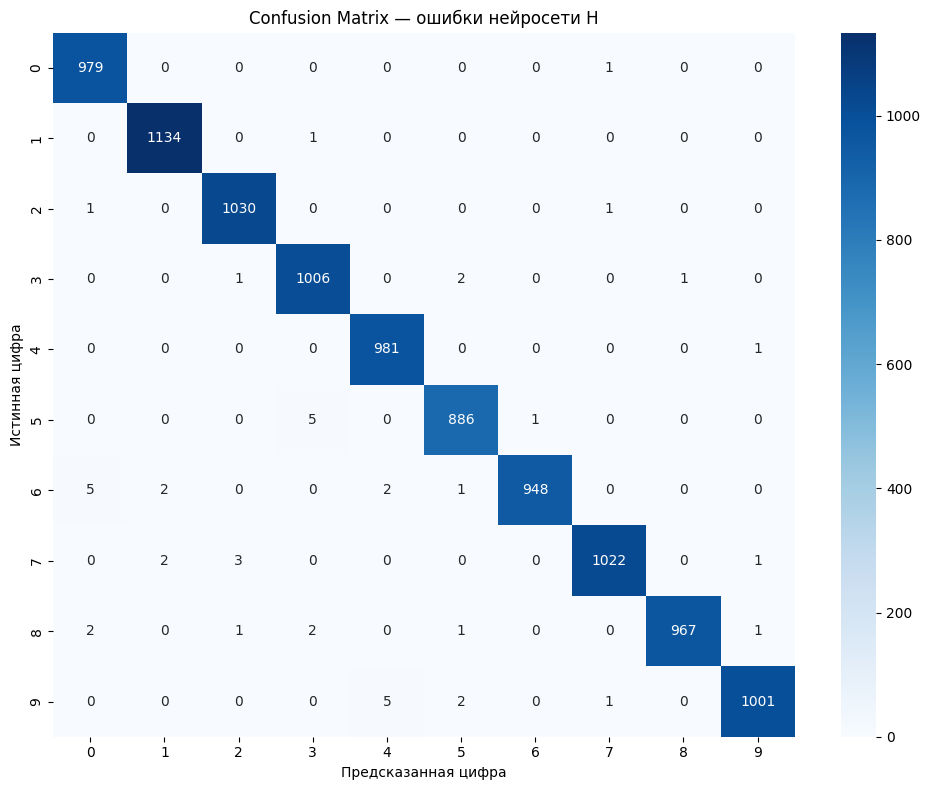


Classification Report (по каждой цифре)
              precision    recall  f1-score   support

           0     0.9919    0.9990    0.9954       980
           1     0.9965    0.9991    0.9978      1135
           2     0.9952    0.9981    0.9966      1032
           3     0.9921    0.9960    0.9941      1010
           4     0.9929    0.9990    0.9959       982
           5     0.9933    0.9933    0.9933       892
           6     0.9989    0.9896    0.9942       958
           7     0.9971    0.9942    0.9956      1028
           8     0.9990    0.9928    0.9959       974
           9     0.9970    0.9921    0.9945      1009

    accuracy                         0.9954     10000
   macro avg     0.9954    0.9953    0.9953     10000
weighted avg     0.9954    0.9954    0.9954     10000


Всего ошибок: 46 из 10000 (0.46%)

Самые частые ошибки (истинная → предсказанная):
  6 → 0: 5 раз(а)
  9 → 4: 5 раз(а)
  5 → 3: 5 раз(а)
  7 → 2: 3 раз(а)
  3 → 5: 2 раз(а)
  8 → 3: 2 раз(а)
  6 → 4:

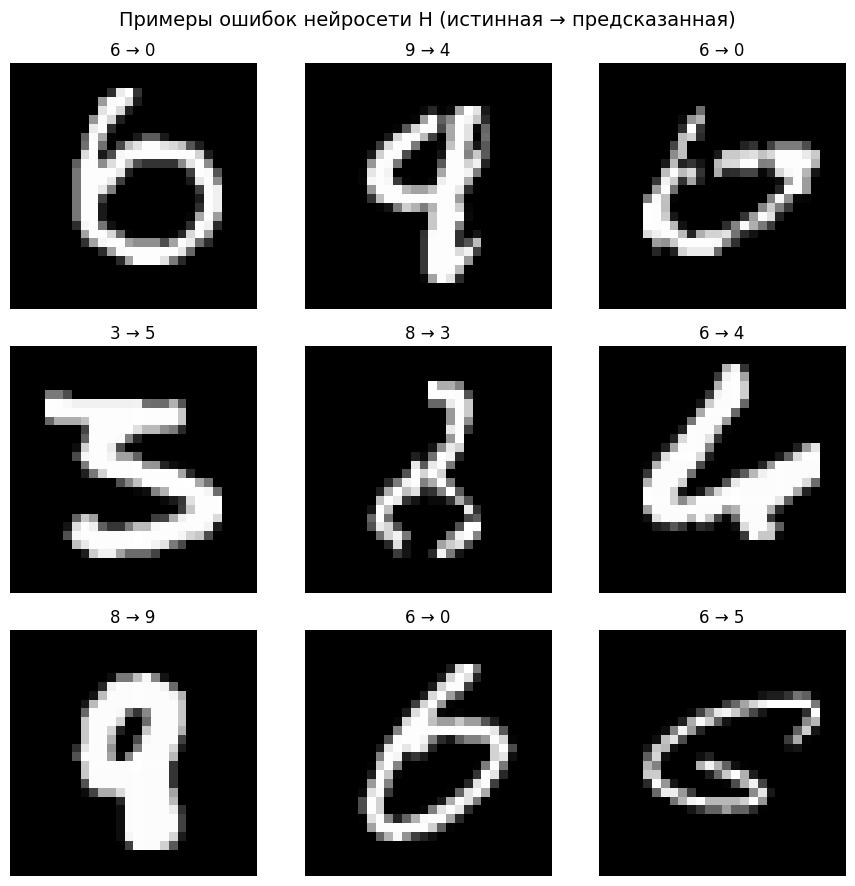


✅ Анализ завершён! Сохранены файлы:
  - confusion_matrix.png
  - error_examples.png


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# ============================================
# 1. Загрузка модели Н (из файла .pth)
# ============================================

# Импортируем класс модели из её кода
import sys
sys.path.append('.')  # добавляем текущую папку в пути
from dataset import MINISTModel  # её класс модели

# Создаём экземпляр модели
model = MINISTModel()

# Загружаем сохранённые веса
model_path = Path("best_model.pth")  # если файл лежит в той же папке
if not model_path.exists():
    # Если нет — попробуй в папке src
    model_path = Path("src/best_model.pth")

model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # переводим в режим оценки (не обучения)
print(f"✅ Модель загружена из {model_path}")

# ============================================
# 2. Загрузка тестовых данных
# ============================================

# Загружаем .npy файлы (путь может отличаться)
data_dir = Path("data/processed")
if not data_dir.exists():
    data_dir = Path("../data/processed")  # может быть на уровень выше

X_test = np.load(data_dir / "test_images.npy")
y_test = np.load(data_dir / "test_labels.npy")

print(f"Тестовых изображений: {len(X_test)}")
print(f"Форма одного изображения: {X_test[0].shape}")

# Превращаем в тензоры PyTorch (как ожидает модель)
# Модель Н ожидает: batch_size × 1 × 28 × 28, значения от 0 до 1
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ============================================
# 3. Предсказания модели на всех тестовых данных
# ============================================

predictions = []
true_labels = []

with torch.no_grad():  # отключаем вычисление градиентов (экономит память)
    for i in range(0, len(X_test_tensor), 128):  # батчами по 128
        batch = X_test_tensor[i:i+128]
        outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.numpy())
        true_labels.extend(y_test_tensor[i:i+128].numpy())

# Превращаем в массивы numpy
y_pred = np.array(predictions)
y_true = np.array(true_labels)

print(f"✅ Предсказания получены. Точность: {(y_pred == y_true).mean()*100:.2f}%")

# ============================================
# 4. Confusion Matrix (матрица ошибок)
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Confusion Matrix — ошибки нейросети Н')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ============================================
# 5. Precision, Recall, F1-score для каждой цифры
# ============================================

print("\n" + "="*60)
print("Classification Report (по каждой цифре)")
print("="*60)
print(classification_report(y_true, y_pred, digits=4))

# ============================================
# 6. Какие цифры путаются чаще всего
# ============================================

# Находим пары цифр, которые модель путает чаще всего
errors = (y_pred != y_true)
error_indices = np.where(errors)[0]

print(f"\nВсего ошибок: {len(error_indices)} из {len(y_true)} ({len(error_indices)/len(y_true)*100:.2f}%)")

# Для каждой пары (истинная → предсказанная) считаем количество ошибок
error_pairs = {}
for i in error_indices:
    true_digit = y_true[i]
    pred_digit = y_pred[i]
    pair = (true_digit, pred_digit)
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

# Сортируем по убыванию
most_common_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nСамые частые ошибки (истинная → предсказанная):")
for (true_digit, pred_digit), count in most_common_errors:
    print(f"  {true_digit} → {pred_digit}: {count} раз(а)")

# ============================================
# 7. Примеры ошибок (показать картинки, которые модель перепутала)
# ============================================

# Возьмём первые 9 ошибок из списка
n_examples = 9
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle('Примеры ошибок нейросети Н (истинная → предсказанная)', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < len(error_indices):
        idx = error_indices[i]
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f"{y_true[idx]} → {y_pred[idx]}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('error_examples.png', dpi=150)
plt.show()

print("\n✅ Анализ завершён! Сохранены файлы:")
print("  - confusion_matrix.png")
print("  - error_examples.png")


Таблица ошибок (только путаница):


,Предсказано 0,Предсказано 1,Предсказано 2,Предсказано 3,Предсказано 4,Предсказано 5,Предсказано 6,Предсказано 7,Предсказано 8,Предсказано 9
Цифра 0,—,—,—,—,—,—,—,1\n(0.1%),—,—
Цифра 1,—,—,—,1\n(0.1%),—,—,—,—,—,—
Цифра 2,1\n(0.1%),—,—,—,—,—,—,1\n(0.1%),—,—
Цифра 3,—,—,1\n(0.1%),—,—,2\n(0.2%),—,—,1\n(0.1%),—
Цифра 4,—,—,—,—,—,—,—,—,—,1\n(0.1%)
Цифра 5,—,—,—,5\n(0.6%),—,—,1\n(0.1%),—,—,—
Цифра 6,5\n(0.5%),2\n(0.2%),—,—,2\n(0.2%),1\n(0.1%),—,—,—,—
Цифра 7,—,2\n(0.2%),3\n(0.3%),—,—,—,—,—,—,1\n(0.1%)
Цифра 8,2\n(0.2%),—,1\n(0.1%),2\n(0.2%),—,1\n(0.1%),—,—,—,1\n(0.1%)
Цифра 9,—,—,—,—,5\n(0.5%),2\n(0.2%),—,1\n(0.1%),—,—



🔍 5 самых частых ошибок:
  1. Цифра 5 → распознана как 3: 5 раз(а) (0.6% от всех 5)
  2. Цифра 6 → распознана как 0: 5 раз(а) (0.5% от всех 6)
  3. Цифра 9 → распознана как 4: 5 раз(а) (0.5% от всех 9)
  4. Цифра 7 → распознана как 2: 3 раз(а) (0.3% от всех 7)
  5. Цифра 3 → распознана как 5: 2 раз(а) (0.2% от всех 3)


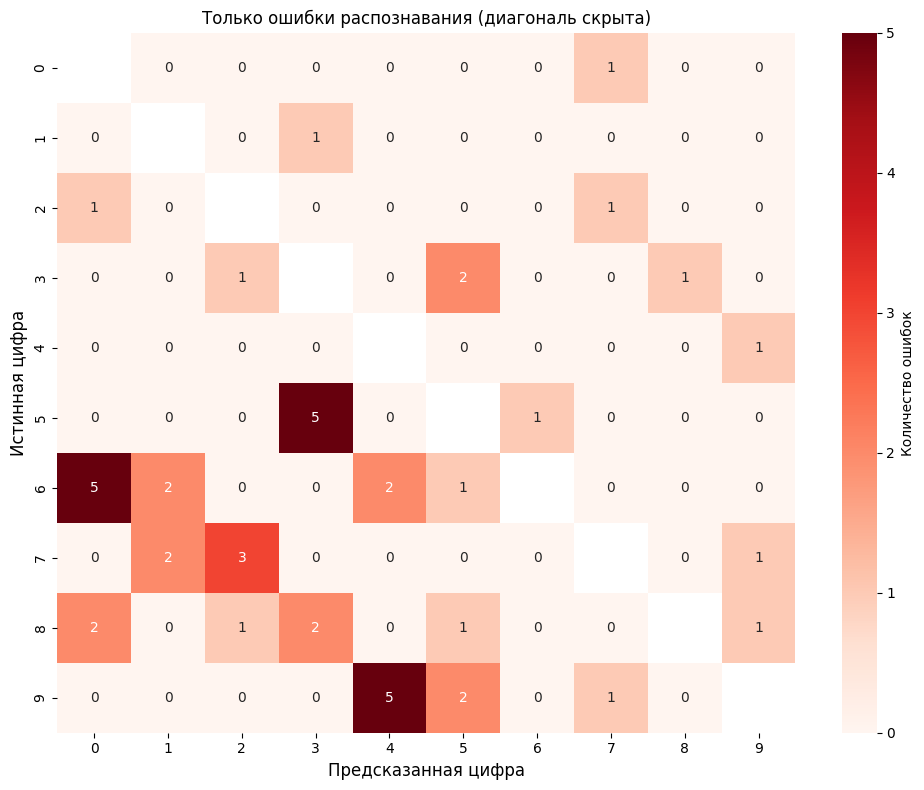

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Предполагается, что y_true и y_pred уже определены

# Вычисляем обычную матрицу ошибок
cm = confusion_matrix(y_true, y_pred)

# Превращаем её в DataFrame для удобной работы
cm_df = pd.DataFrame(cm, index=[f"Цифра {i}" for i in range(10)], 
                     columns=[f"Предсказано {i}" for i in range(10)])

# Создаём копию, где все правильные предсказания (диагональ) и нули заменим на пустоту
cm_errors_only = cm_df.copy().astype(object)  # меняем тип, чтобы можно было вставить текст

for i in range(10):
    for j in range(10):
        if i == j:  # правильные предсказания
            cm_errors_only.iloc[i, j] = "—"
        elif cm_df.iloc[i, j] == 0:  # нет таких ошибок
            cm_errors_only.iloc[i, j] = "—"
        else:  # только ошибочные предсказания
            # Можно добавить процент от всех примеров этого класса
            total_of_class = cm_df.iloc[i, :].sum()
            percent = (cm_df.iloc[i, j] / total_of_class) * 100
            cm_errors_only.iloc[i, j] = f"{cm_df.iloc[i, j]}\n({percent:.1f}%)"

# Выводим таблицу в Jupyter (отображается красиво)
print("\nТаблица ошибок (только путаница):")
display(cm_errors_only)

# Дополнительно: список самых частых ошибок
errors_list = []
for i in range(10):
    for j in range(10):
        if i != j and cm_df.iloc[i, j] > 0:
            total_of_class = cm_df.iloc[i, :].sum()
            percent = (cm_df.iloc[i, j] / total_of_class) * 100
            errors_list.append((i, j, cm_df.iloc[i, j], percent))

# Сортируем по убыванию количества ошибок
errors_list.sort(key=lambda x: x[2], reverse=True)

print("\n🔍 5 самых частых ошибок:")
for idx, (true_digit, pred_digit, count, percent) in enumerate(errors_list[:5]):
    print(f"  {idx+1}. Цифра {true_digit} → распознана как {pred_digit}: {count} раз(а) ({percent:.1f}% от всех {true_digit})")

# Визуализация ошибок (только недиагональные элементы)
plt.figure(figsize=(10, 8))
mask = np.eye(10, dtype=bool)  # маска для диагонали
# Для тепловой карты нужно заполнить диагональ нулями или NaN, чтобы она не окрашивалась
cm_errors_plot = cm.copy().astype(float)
cm_errors_plot[mask] = np.nan

sns.heatmap(cm_errors_plot, annot=True, fmt='.0f', cmap='Reds', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Количество ошибок'}, 
            mask=mask)  # диагональ не окрашивается
plt.xlabel('Предсказанная цифра', fontsize=12)
plt.ylabel('Истинная цифра', fontsize=12)
plt.title('Только ошибки распознавания (диагональ скрыта)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_errors_only.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# Предполагается, что у тебя уже есть:
# - y_true (истинные метки)
# - y_pred (предсказания модели)

# Вычисляем матрицу ошибок
cm = confusion_matrix(y_true, y_pred)

# Количество классов
n_classes = cm.shape[0]

# Создаём списки для хранения метрик
precision = []
recall = []
f1 = []
specificity = []

# Для каждого класса считаем метрики
for i in range(n_classes):
    TP = cm[i, i]                      # True Positive
    FP = cm[:, i].sum() - TP           # False Positive
    FN = cm[i, :].sum() - TP           # False Negative
    TN = cm.sum() - (TP + FP + FN)     # True Negative
    
    # Precision (точность): из предсказанных i сколько действительно i
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    precision.append(prec)
    
    # Recall (полнота): из реальных i сколько найдено
    rec = TP / (TP + FN) if (TP + FN) > 0 else 0
    recall.append(rec)
    
    # F1-score: среднее гармоническое precision и recall
    f1_score = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    f1.append(f1_score)
    
    # Specificity (специфичность): из не-i сколько правильно отнесено к не-i
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)

# Создаём DataFrame с результатами
results_df = pd.DataFrame({
    'Цифра': [f'{i}' for i in range(n_classes)],
    'Precision (точность)': [f'{p:.3f}' for p in precision],
    'Recall (полнота)': [f'{r:.3f}' for r in recall],
    'F1-score': [f'{f:.3f}' for f in f1],
    'Specificity (специфичность)': [f'{s:.3f}' for s in specificity],
})

# Вычисляем средние (macro average)
avg_precision = np.mean(precision)
avg_recall = np.mean(recall)
avg_f1 = np.mean(f1)
avg_specificity = np.mean(specificity)

# Добавляем строку со средними значениями
avg_row = pd.DataFrame({
    'Цифра': ['СРЕДНЕЕ'],
    'Precision (точность)': [f'{avg_precision:.3f}'],
    'Recall (полнота)': [f'{avg_recall:.3f}'],
    'F1-score': [f'{avg_f1:.3f}'],
    'Specificity (специфичность)': [f'{avg_specificity:.3f}'],
})
results_df = pd.concat([results_df, avg_row], ignore_index=True)

# Выводим красивую таблицу
print("\n" + "="*70)
print("МЕТРИКИ ДЛЯ КАЖДОЙ ЦИФРЫ")
print("="*70)
print()
display(results_df)  # Красивый вывод в Jupyter

# Или если display не работает, используй print
# print(results_df.to_string(index=False))

# Дополнительно: выводим пояснения
print("\n" + "="*70)
print("ЧТО ОЗНАЧАЮТ МЕТРИКИ:")
print("="*70)
print("""
• Precision (точность) — из всех, кого модель назвала цифрой X, сколько действительно X.
  Высокий precision = мало ложных срабатываний (модель редко ошибается, называя чужую цифру X).

• Recall (полнота) — из всех реальных цифр X, сколько модель нашла.
  Высокий recall = модель редко пропускает эту цифру.

• F1-score — среднее гармоническое precision и recall.
  Хороший баланс между точностью и полнотой.

• Specificity (специфичность) — из всех НЕ-X, сколько модель правильно определила как НЕ-X.
  Высокая specificity = модель редко ошибочно принимает другие цифры за X.
""")


МЕТРИКИ ДЛЯ КАЖДОЙ ЦИФРЫ



,Цифра,Precision (точность),Recall (полнота),F1-score,Specificity (специфичность)
0,0,0.992,0.999,0.995,0.999
1,1,0.996,0.999,0.998,1.000
2,2,0.995,0.998,0.997,0.999
3,3,0.992,0.996,0.994,0.999
4,4,0.993,0.999,0.996,0.999
5,5,0.993,0.993,0.993,0.999
6,6,0.999,0.990,0.994,1.000
7,7,0.997,0.994,0.996,1.000
8,8,0.999,0.993,0.996,1.000
9,9,0.997,0.992,0.995,1.000



ЧТО ОЗНАЧАЮТ МЕТРИКИ:

• Precision (точность) — из всех, кого модель назвала цифрой X, сколько действительно X.
  Высокий precision = мало ложных срабатываний (модель редко ошибается, называя чужую цифру X).

• Recall (полнота) — из всех реальных цифр X, сколько модель нашла.
  Высокий recall = модель редко пропускает эту цифру.

• F1-score — среднее гармоническое precision и recall.
  Хороший баланс между точностью и полнотой.

• Specificity (специфичность) — из всех НЕ-X, сколько модель правильно определила как НЕ-X.
  Высокая specificity = модель редко ошибочно принимает другие цифры за X.

